# Plot all the GSEA and ORA

In [73]:
import os
from plot_GSEA_ORA import *
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import ttest_ind
from collections import Counter

In [74]:
ora_fdr = 0.15
gsea_fdr=0.01
gsea_nes= 2
score_name='stat'

## ORA

Get all the ORAs I have

In [2]:

# Directory containing the files
directory = "../data"

# List to store dictionaries
files_list = []

# Iterate through the files in the directory
for filename in os.listdir(directory):
    if filename.endswith("ORA.csv"):
        file_path = os.path.join(directory, filename)
        # Append the file information to the list as a dictionary
        files_list.append({"filename": filename, "path": file_path})
files_list

[{'filename': 'RNAseq_abundances_adjusted_combat_inmose_young.vs.old_ORA.csv',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_ORA.csv'},
 {'filename': 'feature_importance_ridge_smote_7b_age_ORA.csv',
  'path': '../data/feature_importance_ridge_smote_7b_age_ORA.csv'},
 {'filename': 'feature_importance_smote_catboost_7b_gene_ranking_07_age_ORA.csv',
  'path': '../data/feature_importance_smote_catboost_7b_gene_ranking_07_age_ORA.csv'}]

In [4]:
def prepare_ORA(filename, path):
    ora_df = pd.read_csv(path, index_col=0)
    ora_df=ora_df[ora_df['FDR p-value']<ora_fdr]
    fig, ax = plot_ora_results(ora_df, title= filename)
    return fig
    

    
    

In [5]:
def create_ORA_pdf(files_list, output_file, title="ORA results"):
    with PdfPages(output_file) as pdf:
        # Create the index page
        fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size page
        
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Title for the index
        ax.text(0.5, 0.95, title, ha='center', fontsize=16, fontweight='bold')
        
        # Generate index with clickable links (not yet, just a visual index)
        y_position = 0.9
        for i, file_dict in enumerate(files_list):
            # Add gene name to the index
            name=file_dict['filename']
            ax.text(0.1, y_position - (i * 0.04), f"{i+1}. {name}", fontsize=12, ha='left')
        
        # Save index page
        pdf.savefig(fig)
        plt.close(fig)

        # Create violin plots for each gene using the modified function
        for file_dict in files_list:
            filename= file_dict['filename']
            path = file_dict['path']
            # Generate the violin plot and return the figure
            fig = prepare_ORA(filename=filename, path=path)
            
            # Save the figure to the PDF
            pdf.savefig(fig)
            
            # Close the figure after saving it to free up memory
            plt.close(fig)


In [9]:
create_ORA_pdf(files_list, output_file="../data/ALL_ORAs.pdf", title="ORA results")

/home/amore/work/notebooks/plot_GSEA_ORA.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=12)
/home/amore/work/notebooks/plot_GSEA_ORA.py:114: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/home/amore/work/notebooks/plot_GSEA_ORA.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=12)
/home/amore/work/notebooks/plot_GSEA_ORA.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=12)


## GSEA

In [11]:

# List to store dictionaries
files_list_gsea = []

# Iterate through the files in the directory
for filename in os.listdir(directory):
    if filename.endswith("GSEA.csv"):
        file_path = os.path.join(directory, filename)
        # Append the file information to the list as a dictionary
        files_list_gsea.append({"filename": filename, "path": file_path})
files_list_gsea

[{'filename': 'feature_importance_smote_catboost_7b_gene_ranking_07_age_GSEA.csv',
  'path': '../data/feature_importance_smote_catboost_7b_gene_ranking_07_age_GSEA.csv'},
 {'filename': 'RNAseq_abundances_adjusted_combat_inmose_young.vs.old_GSEA.csv',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_GSEA.csv'},
 {'filename': 'feature_importance_ridge_smote_7b_age_GSEA.csv',
  'path': '../data/feature_importance_ridge_smote_7b_age_GSEA.csv'}]

In [17]:
missing=[]
files_list_gsea_new = []
for file in files_list_gsea[:]:
    base = file['path'].replace('_GSEA','').replace('_GSEA','')
    if os.path.isfile(base):
        file['scores'] = base
        files_list_gsea_new.append(file)
    else:
        missing.append(base)

files_list_gsea_new

[]

In [ ]:
work/data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv

In [82]:
files_list_gsea = [
{'filename': 'Catboost 7%',
  'path': '../data/feature_importance_smote_catboost_7b_gene_ranking_07_age_GSEA.csv',
  'score':'../data/feature_importance_smote_catboost_7b_gene_ranking_07.csv',
  'score_name':'coef'},

 {'filename': 'Ridge 40%',
  'path': '../data/feature_importance_ridge_smote_7b_age_GSEA.csv',
  'score': '../data/feature_importance_ridge_smote_7b_SYMBOLS.csv',
 'score_name':'Importance'},

  {'filename': 'Differential expression young vs middle age',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.middle_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.middle_DDS.csv',
  'score_name':'stat'},

   {'filename': 'Differential expression middle age vs old',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_middle.vs.old_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_middle.vs.old_DDS.csv',
  'score_name':'stat'},

   {'filename': 'Differential expression young vs old',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv',
  'score_name':'stat'}
 ]

In [53]:
missing=[]
for file in files_list_gsea[:]:
    base = file['score']
    if os.path.isfile(base):
        pass
    else:
        missing.append(base)
missing

[]

In [4]:
msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')

/tmp/ipykernel_51662/3954172370.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')


In [5]:
def get_terms_interest(filename, path):
    gsea_df = pd.read_csv(path, index_col=0)
    gsea_df=gsea_df[gsea_df['FDR p-value']<gsea_fdr]
    gsea_df=gsea_df[abs(gsea_df['NES'])>gsea_nes]
    terms = gsea_df['Term']
    return list(terms)
    

In [77]:

def get_gsea_figure(filename,score_file,score_name,msigdb,term):
    gsea_scores = pd.read_csv(score_file,index_col=0)
    gsea_scores=pd.DataFrame(gsea_scores[score_name])
    fig,ax = plot_gsea_results(gsea_scores=gsea_scores, score_name=score_name, msigdb=msigdb, term=term)
    
    return fig
    

            stat
TSPAN6 -0.373394
TNMD   -0.305723
DPM1   -0.922960


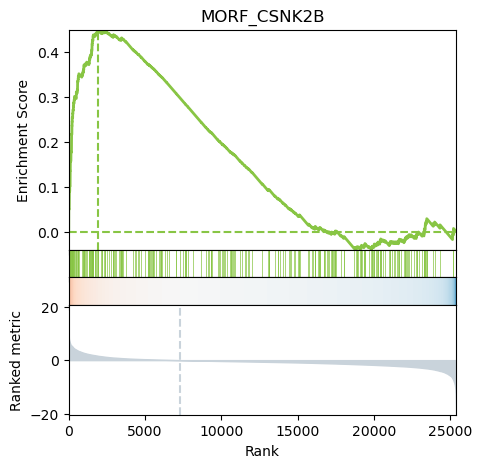

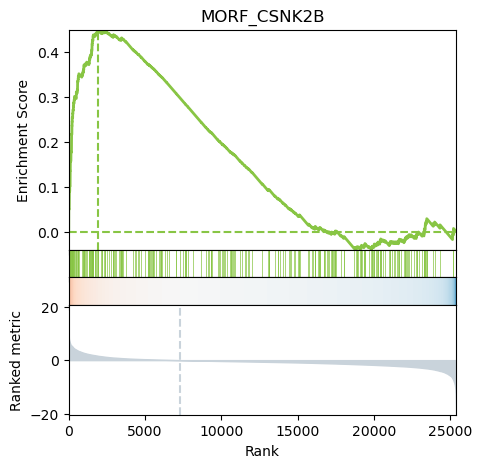

In [76]:
get_gsea_figure(filename,score_file,score_name,msigdb_extended,'MORF_CSNK2B')

In [83]:
terms=[]
for file in files_list_gsea:
    terms.extend(get_terms_interest(file['filename'], file['path']))


In [84]:
len(set(terms))

1858

In [90]:
string_counts = Counter(terms)

# Keep only elements that repeat at least once
repeated_elements = [item for item in terms if string_counts[item] > 1]

# Remove duplicates from the result to keep only unique repeated elements
unique_repeated_elements = list(set(repeated_elements))
len(unique_repeated_elements)

119

In [87]:
unique_repeated_elements2

['STEIN_ESRRA_TARGETS_UP',
 'GOBP_ATP_METABOLIC_PROCESS',
 'GOMF_PRIMARY_ACTIVE_TRANSMEMBRANE_TRANSPORTER_ACTIVITY',
 'MOOTHA_PGC',
 'MORF_SOD1',
 'MOOTHA_HUMAN_MITODB_6_2002',
 'MORF_CSNK2B',
 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
 'MOOTHA_MITOCHONDRIA']

In [79]:
def create_GSEA_pdf(files_list, output_file, terms,msigdb,title="GSEA results"):
    with PdfPages(output_file) as pdf:
        # Create the index page
        fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size page
        
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Title for the index
        ax.text(0.5, 0.95, title, ha='center', fontsize=16, fontweight='bold')
        
        # Generate index with clickable links (not yet, just a visual index)
        y_position = 0.9
        for i, file_dict in enumerate(files_list):
            # Add gene name to the index
            name=file_dict['filename']
            ax.text(0.1, y_position - (i * 0.04), f"{i+1}. {name}", fontsize=12, ha='left')
        
        # Save index page
        pdf.savefig(fig)
        plt.close(fig)

        # Create violin plots for each gene using the modified function
        for term in terms:
            print(term)
            for file_dict in files_list:
                filename= file_dict['filename']
                path = file_dict['path']
                score_file= file_dict['score']
                score_name = file_dict['score_name']
                print(score_name)
                try:
                # Generate the violin plot and return the figure
                    fig = get_gsea_figure(filename,score_file,score_name,msigdb,term)
                    fig.suptitle(f"{filename}", fontsize=10, fontweight='bold')
                    
                except Exception as e:
                    print(f'fail in {filename}: {e}')
                    plt.close(fig)
                    continue
                # Save the figure to the PDF
                pdf.savefig(fig)
                
                # Close the figure after saving it to free up memory
                plt.close(fig)


In [92]:
create_GSEA_pdf(files_list = files_list_gsea, output_file="../data/all_GSEA.pdf", terms=unique_repeated_elements,msigdb=msigdb_extended,title="GSEA results")


HP_FLUCTUATIONS_IN_CONSCIOUSNESS
coef
Importance
stat
stat
stat
HP_INCREASED_CSF_LACTATE
coef
Importance
stat
stat
stat
GOCC_NADH_DEHYDROGENASE_COMPLEX
coef
Importance
stat
stat
stat
HP_DISTAL_PERIPHERAL_SENSORY_NEUROPATHY
coef
Importance
stat
stat
stat
MANNO_MIDBRAIN_NEUROTYPES_BASAL
coef
Importance
stat
stat
stat
MORF_TPT1
coef
Importance
stat
stat
stat
GOBP_ATP_SYNTHESIS_COUPLED_ELECTRON_TRANSPORT
coef
Importance
stat
stat
stat
HP_MULTIPLE_GLOMERULAR_CYSTS
coef
fail in Catboost 7%: No sources with more than min_n=0 targets. Make sure mat and net have shared target features or
        reduce the number assigned to min_n
Importance
stat
stat
stat
HP_FOCAL_T2_HYPERINTENSE_BRAINSTEM_LESION
coef
Importance
stat
stat
stat
HP_OPTIC_NEUROPATHY
coef
Importance
stat
stat
stat
HP_MUSCLE_ABNORMALITY_RELATED_TO_MITOCHONDRIAL_DYSFUNCTION
coef
Importance
stat
stat
stat
HP_CONCENTRIC_HYPERTROPHIC_CARDIOMYOPATHY
coef
fail in Catboost 7%: No sources with more than min_n=0 targets. Make sure mat and n

In [20]:
pwd

'/home/amore/work/notebooks'